# 🛍️ Shopping Mall Customer Segmentation
## Member X — Gaussian Mixture Model (GMM)
**Dataset:** Shopping_Mall_Customer_Segmentation_Data_.csv  
**Algorithm:** Gaussian Mixture Model (GMM)  
**Task:** Unsupervised Learning — Customer Segmentation

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Load Pre-processed Data
> Data was already cleaned and scaled in `step0_eda_preprocessing.ipynb`.


In [2]:
import numpy as np
import pandas as pd
import joblib

X_final = np.load("X_final.npy")
scaler = joblib.load("scaler.pkl")
pca = joblib.load("pca.pkl")

df_clean = pd.read_csv('data/data_preprocessed.csv')
df = pd.read_csv('data/Shopping Mall Customer Segmentation Data .csv')

print('✅ Loaded X_final.npy shape:', X_final.shape)
print('✅ Loaded scaler.pkl')
print('✅ Loaded pca.pkl')
print('✅ Loaded data_preprocessed.csv shape:', df_clean.shape)
print('✅ Loaded original CSV shape:', df.shape)

✅ Loaded X_final.npy shape: (15079, 4)
✅ Loaded scaler.pkl
✅ Loaded pca.pkl
✅ Loaded data_preprocessed.csv shape: (15079, 4)
✅ Loaded original CSV shape: (15079, 5)


## 3. Select Optimal Number of Clusters (BIC)
> GMM does not use bandwidth like MeanShift.  
> Instead, we test different values of **K** and choose the best one using **BIC** (lower is better).


In [3]:
bic_scores = []
aic_scores = []
k_range = range(2, 10)

for k in k_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_final)
    bic_scores.append(gmm.bic(X_final))
    aic_scores.append(gmm.aic(X_final))

best_k = 3

## 4. BIC / AIC Visualization

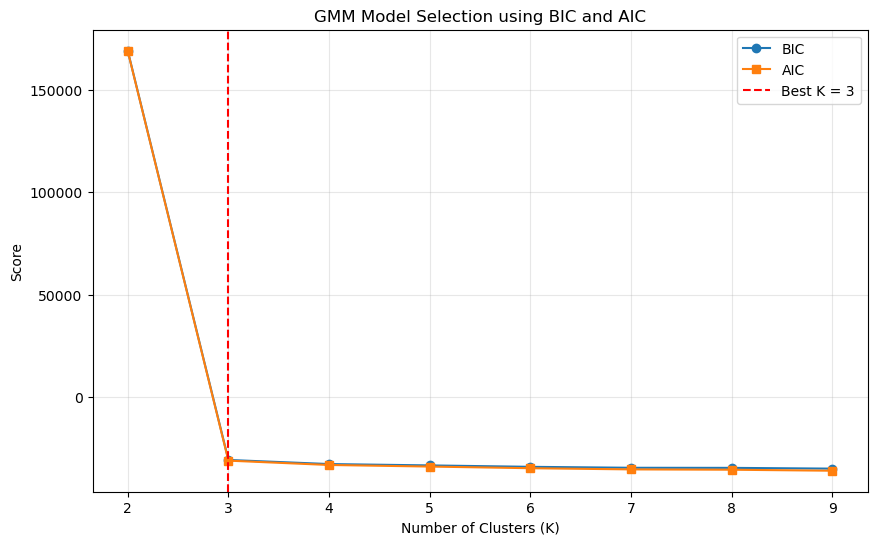

In [4]:
plt.figure(figsize=(10, 6))
plt.plot(list(k_range), bic_scores, marker='o', label='BIC')
plt.plot(list(k_range), aic_scores, marker='s', label='AIC')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best K = {best_k}')

plt.title('GMM Model Selection using BIC and AIC')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Score')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 5. Train GMM Model
> Train the final Gaussian Mixture Model using the selected number of clusters.


In [5]:
gmm = GaussianMixture(
    n_components=best_k,
    covariance_type='full',
    random_state=42,
    n_init=5
)
gmm.fit(X_final)

cluster_labels = gmm.predict(X_final)
cluster_probs = gmm.predict_proba(X_final)
n_clusters = len(np.unique(cluster_labels))

print(f'Number of clusters found by GMM: {n_clusters}')
print('\nCluster Distribution:')
unique, counts = np.unique(cluster_labels, return_counts=True)
for c, cnt in zip(unique, counts):
    print(f'  Cluster {c}: {cnt} customers ({cnt/len(df)*100:.1f}%)')

df_clean['Cluster'] = cluster_labels
df['Cluster'] = cluster_labels

Number of clusters found by GMM: 3

Cluster Distribution:
  Cluster 0: 7484 customers (49.6%)
  Cluster 1: 3916 customers (26.0%)
  Cluster 2: 3679 customers (24.4%)


## 6. Evaluation Metrics

In [6]:
sil = silhouette_score(X_final, cluster_labels)
dbi = davies_bouldin_score(X_final, cluster_labels)

print('=' * 45)
print('        GMM EVALUATION METRICS')
print('=' * 45)
print(f'  Best K Selected     : {best_k}')
print(f'  Silhouette Score    : {sil:.4f}  (closer to 1 = better)')
print(f'  Davies-Bouldin Index: {dbi:.4f}  (closer to 0 = better)')
print(f'  Final BIC Score     : {gmm.bic(X_final):.2f}')
print(f'  Final AIC Score     : {gmm.aic(X_final):.2f}')
print('=' * 45)

        GMM EVALUATION METRICS
  Best K Selected     : 3
  Silhouette Score    : 0.2221  (closer to 1 = better)
  Davies-Bouldin Index: 1.5704  (closer to 0 = better)
  Final BIC Score     : -32145.71
  Final AIC Score     : -32481.03


## 7. Cluster Visualization (PCA 2D)

In [7]:
from sklearn.decomposition import PCA

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_final)
gmm_means_3d = pca_3d.transform(gmm.means_)

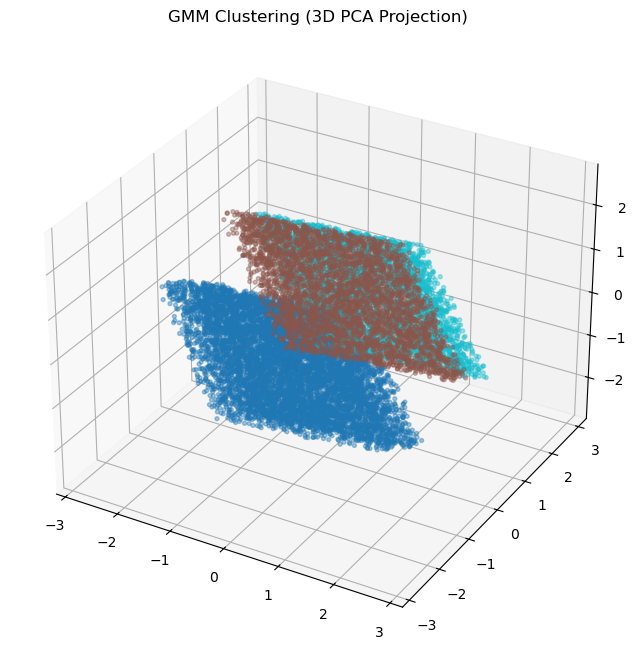

In [8]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_pca_3d[:, 0],
    X_pca_3d[:, 1],
    X_pca_3d[:, 2],
    c=cluster_labels,
    cmap='tab10',
    s=8,
    alpha=0.4
)

ax.scatter(
    gmm_means_3d[:, 0],
    gmm_means_3d[:, 1],
    gmm_means_3d[:, 2],
    c='black',
    s=250,
    marker='*'
)

ax.set_title("GMM Clustering (3D PCA Projection)")
plt.show()

## 8. Cluster Profile Analysis

In [9]:
profile = df.groupby('Cluster')[['Age', 'Annual Income', 'Spending Score']].mean().round(2)
profile['Count'] = df.groupby('Cluster')['Age'].count()
profile['% of Total'] = (profile['Count'] / len(df) * 100).round(2)
print('Cluster Profiles:')
profile

Cluster Profiles:


,Age,Annual Income,Spending Score,Count,% of Total
Cluster,,,,,
0,54.15,109902.80,50.40,7484,49.63
1,53.88,65770.49,49.74,3916,25.97
2,54.61,156222.65,51.89,3679,24.40


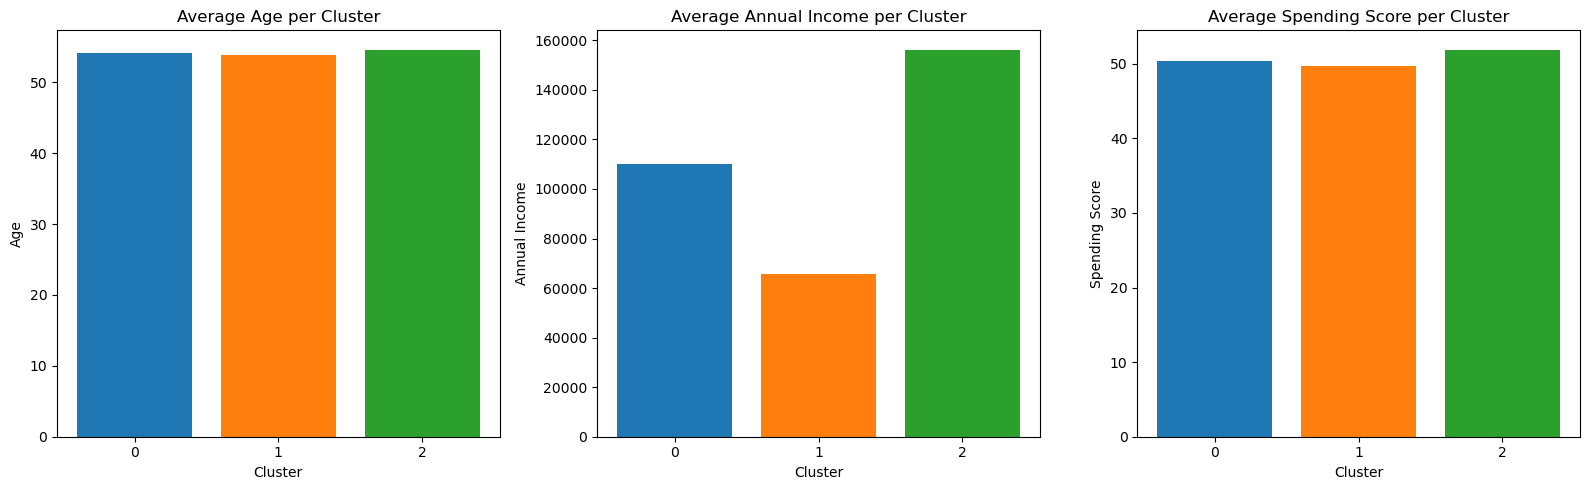

In [10]:
# Bar chart of cluster averages
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
features = ['Age', 'Annual Income', 'Spending Score']
palette_bar = sns.color_palette('tab10', n_clusters)

for i, feat in enumerate(features):
    cluster_means = df.groupby('Cluster')[feat].mean()
    axes[i].bar(cluster_means.index.astype(str), cluster_means.values, color=palette_bar)
    axes[i].set_title(f'Average {feat} per Cluster')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel(feat)

plt.tight_layout()
plt.savefig('gmm_cluster_profiles.png', dpi=150)
plt.show()

## 9. Membership Probability Analysis

In [11]:
prob_df = pd.DataFrame(cluster_probs, columns=[f'Prob_Cluster_{i}' for i in range(n_clusters)])
prob_df['Predicted_Cluster'] = cluster_labels

print('First 10 customers with cluster membership probabilities:')
prob_df.head(10)

First 10 customers with cluster membership probabilities:


,Prob_Cluster_0,Prob_Cluster_1,Prob_Cluster_2,Predicted_Cluster
0,0.0,0.010636,0.989364,2
1,1.0,0.000000,0.000000,0
2,1.0,0.000000,0.000000,0
3,0.0,0.998393,0.001607,1
4,0.0,0.009030,0.990970,2
5,0.0,0.006578,0.993422,2
6,1.0,0.000000,0.000000,0
7,0.0,0.993308,0.006692,1
8,0.0,0.999208,0.000792,1
9,1.0,0.000000,0.000000,0


## 10. Summary

In [12]:
print('=' * 55)
print('         GMM CLUSTERING — FINAL SUMMARY')
print('=' * 55)
print(f'  Algorithm             : Gaussian Mixture Model (GMM)')
print(f'  Best K Selected       : {best_k}')
print(f'  Covariance Type       : full')
print(f'  Total Customers       : {len(df)}')
print(f'  Silhouette Score      : {sil:.4f}')
print(f'  Davies-Bouldin Index  : {dbi:.4f}')
print(f'  Final BIC Score       : {gmm.bic(X_final):.2f}')
print('=' * 55)
print('\nKey advantage of GMM:')
print('  - Provides soft clustering using membership probabilities')
print('  - Can model overlapping clusters better than K-Means')

         GMM CLUSTERING — FINAL SUMMARY
  Algorithm             : Gaussian Mixture Model (GMM)
  Best K Selected       : 3
  Covariance Type       : full
  Total Customers       : 15079
  Silhouette Score      : 0.2221
  Davies-Bouldin Index  : 1.5704
  Final BIC Score       : -32145.71

Key advantage of GMM:
  - Provides soft clustering using membership probabilities
  - Can model overlapping clusters better than K-Means


---
# 🔮 Predict Customer Segment
> Enter a new customer's details below and the trained model will predict which segment they belong to.


In [ ]:
# ============================================================
#  ✏️  ENTER CUSTOMER DETAILS HERE
# ============================================================
input_age            = int(input('Enter Age           : '))
input_gender         = input('Enter Gender        (Male/Female): ').strip().capitalize()
input_annual_income  = float(input('Enter Annual Income : '))
input_spending_score = float(input('Enter Spending Score (1-100): '))

gender_encoded = 0 if input_gender == 'Female' else 1

# original input
new_customer = np.array([[input_age, gender_encoded, input_annual_income, input_spending_score]])

# same preprocessing pipeline as training
new_customer_scaled = scaler.transform(new_customer)
new_customer_final  = pca.transform(new_customer_scaled)

# predict in PCA space
predicted_cluster = gmm.predict(new_customer_final)[0]
membership_probs  = gmm.predict_proba(new_customer_final)[0]

# profile from original feature space
cluster_profile = df[df['Cluster'] == predicted_cluster][['Age', 'Annual Income', 'Spending Score']].mean()
cluster_size = (df['Cluster'] == predicted_cluster).sum()

print()
print('=' * 55)
print('             GMM — PREDICTION RESULT')
print('=' * 55)
print(f'  Input  → Age: {input_age}, Gender: {input_gender}')
print(f'           Annual Income: {input_annual_income:,.0f}')
print(f'           Spending Score: {input_spending_score:.1f}')
print()
print(f'  ✅ Predicted Cluster : {predicted_cluster}')
print(f'  👥 Cluster Size      : {cluster_size} customers')
print()
print('  Cluster Membership Probabilities:')
for i, prob in enumerate(membership_probs):
    print(f'    Cluster {i}: {prob:.4f}')
print()
print('  Cluster Average Profile:')
print(f'    Average Age           : {cluster_profile["Age"]:.1f}')
print(f'    Average Annual Income : {cluster_profile["Annual Income"]:,.0f}')
print(f'    Average Spending Score: {cluster_profile["Spending Score"]:.1f}')
print('=' * 55)

In [ ]:
cluster_data = df[df['Cluster'] == predicted_cluster][['Age', 'Annual Income', 'Spending Score']]

print("\n  Cluster Range:")
print(f"    Age Range           : {cluster_data['Age'].min()} - {cluster_data['Age'].max()}")
print(f"    Annual Income Range : {cluster_data['Annual Income'].min():,.0f} - {cluster_data['Annual Income'].max():,.0f}")
print(f"    Spending Score Range: {cluster_data['Spending Score'].min():.0f} - {cluster_data['Spending Score'].max():.0f}")

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pandas as pd

# ============================================================
#  PCA → 3D（只用于 visualization）
# ============================================================
pca_3d = PCA(n_components=3)

X_3d = pca_3d.fit_transform(X_final)
new_3d = pca_3d.transform(new_customer_final)

# ============================================================
#  3D PLOT
# ============================================================
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

palette = sns.color_palette('tab10', n_clusters)

for c in range(n_clusters):
    mask = cluster_labels == c

    # 目标 cluster 稍微明显，其他 cluster 更淡
    alpha = 0.20 if c == predicted_cluster else 0.07
    size = 12 if c == predicted_cluster else 8

    ax.scatter(
        X_3d[mask, 0],
        X_3d[mask, 1],
        X_3d[mask, 2],
        color=palette[c],
        alpha=alpha,
        s=size,
        label=f'Cluster {c}' if c != predicted_cluster else f'Cluster {c} ← YOU',
        depthshade=False
    )

# ⭐ 新顾客（一定最后画）
ax.scatter(
    new_3d[0, 0],
    new_3d[0, 1],
    new_3d[0, 2],
    marker='*',
    s=900,                 # 放大很多
    c='blue',               # 改成红色更明显
    edgecolors='black',    # 黑边
    linewidths=2.0,
    label='New Customer',
    depthshade=False
)

# 可选：在星星旁边加文字
ax.text(
    new_3d[0, 0],
    new_3d[0, 1],
    new_3d[0, 2],
    '  YOU',
    color='black',
    fontsize=10,
    fontweight='bold'
)

# ============================================================
#  LABELS
# ============================================================
ax.set_title(f'GMM — New Customer in Cluster {predicted_cluster}', fontsize=14, fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

ax.legend(loc='best', fontsize=8) 
plt.tight_layout()

df_plot = pd.DataFrame({
    'PC1': X_3d[:, 0],
    'PC2': X_3d[:, 1],
    'PC3': X_3d[:, 2],
    'Cluster': cluster_labels
})

fig = px.scatter_3d(
    df_plot,
    x='PC1',
    y='PC2',
    z='PC3',
    color='Cluster',
    opacity=0.25
)

# 加新 customer
fig.add_scatter3d(
    x=[new_3d[0, 0]],
    y=[new_3d[0, 1]],
    z=[new_3d[0, 2]],
    mode='markers',
    marker=dict(size=18, color='lime', symbol='diamond', line=dict(color='black', width=10)),
    name='New Customer'
)

fig.show()

In [ ]:
import pandas as pd

feature_names = ['Age', 'Gender', 'Annual Income', 'Spending Score']

# PCA weights（最重要）
pca_components = pd.DataFrame(
    pca.components_,
    columns=feature_names,
    index=[f'PC{i+1}' for i in range(pca.n_components_)]
)

print("PCA Components (Feature Contributions):")
print(pca_components)

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)
print("Total Variance Retained:", sum(pca.explained_variance_ratio_))